In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings("ignore")

In [3]:
train_df = pd.read_csv("/content/dataset/DailyDelhiClimateTrain.csv")
test_df = pd.read_csv("/content/dataset/DailyDelhiClimateTest.csv")
train_df.head()

,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000


In [4]:
print("Training Data Shape:", train_df.shape)
print("Testing Data Shape:", test_df.shape)

Training Data Shape: (1462, 5)
Testing Data Shape: (114, 5)


In [5]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1462 entries, 0 to 1461
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          1462 non-null   object 
 1   meantemp      1462 non-null   float64
 2   humidity      1462 non-null   float64
 3   wind_speed    1462 non-null   float64
 4   meanpressure  1462 non-null   float64
dtypes: float64(4), object(1)
memory usage: 57.2+ KB


In [6]:
train_df.describe()

,meantemp,humidity,wind_speed,meanpressure
count,1462.000000,1462.000000,1462.000000,1462.000000
mean,25.495521,60.771702,6.802209,1011.104548
std,7.348103,16.769652,4.561602,180.231668
min,6.000000,13.428571,0.000000,-3.041667
25%,18.857143,50.375000,3.475000,1001.580357
50%,27.714286,62.625000,6.221667,1008.563492
75%,31.305804,72.218750,9.238235,1014.944901
max,38.714286,100.000000,42.220000,7679.333333


In [7]:
print("Missing Values in Training Data:")
print(train_df.isnull().sum())

print("\nMissing Values in Testing Data:")
print(test_df.isnull().sum())

Missing Values in Training Data:
date            0
meantemp        0
humidity        0
wind_speed      0
meanpressure    0
dtype: int64

Missing Values in Testing Data:
date            0
meantemp        0
humidity        0
wind_speed      0
meanpressure    0
dtype: int64


In [8]:
# Remove duplicate rows
train_df = train_df.drop_duplicates()
test_df = test_df.drop_duplicates()

# Convert date column to datetime format
train_df['date'] = pd.to_datetime(train_df['date'])
test_df['date'] = pd.to_datetime(test_df['date'])

# Check updated data types
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1462 entries, 0 to 1461
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          1462 non-null   datetime64[ns]
 1   meantemp      1462 non-null   float64       
 2   humidity      1462 non-null   float64       
 3   wind_speed    1462 non-null   float64       
 4   meanpressure  1462 non-null   float64       
dtypes: datetime64[ns](1), float64(4)
memory usage: 57.2 KB


In [9]:
# Extract year, month, and day from date
train_df['year'] = train_df['date'].dt.year
train_df['month'] = train_df['date'].dt.month
train_df['day'] = train_df['date'].dt.day

test_df['year'] = test_df['date'].dt.year
test_df['month'] = test_df['date'].dt.month
test_df['day'] = test_df['date'].dt.day

train_df.head()

,date,meantemp,humidity,wind_speed,meanpressure,year,month,day
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667,2013,1,1
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000,2013,1,2
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667,2013,1,3
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667,2013,1,4
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000,2013,1,5


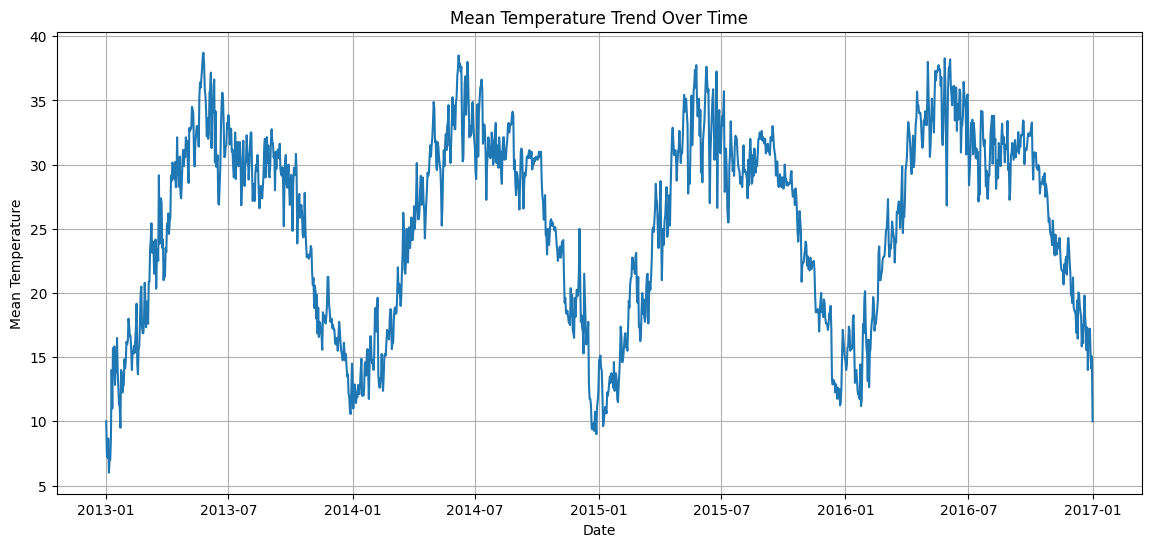

In [10]:
plt.figure(figsize=(14,6))
plt.plot(train_df['date'], train_df['meantemp'])
plt.title("Mean Temperature Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Mean Temperature")
plt.grid(True)
plt.show()

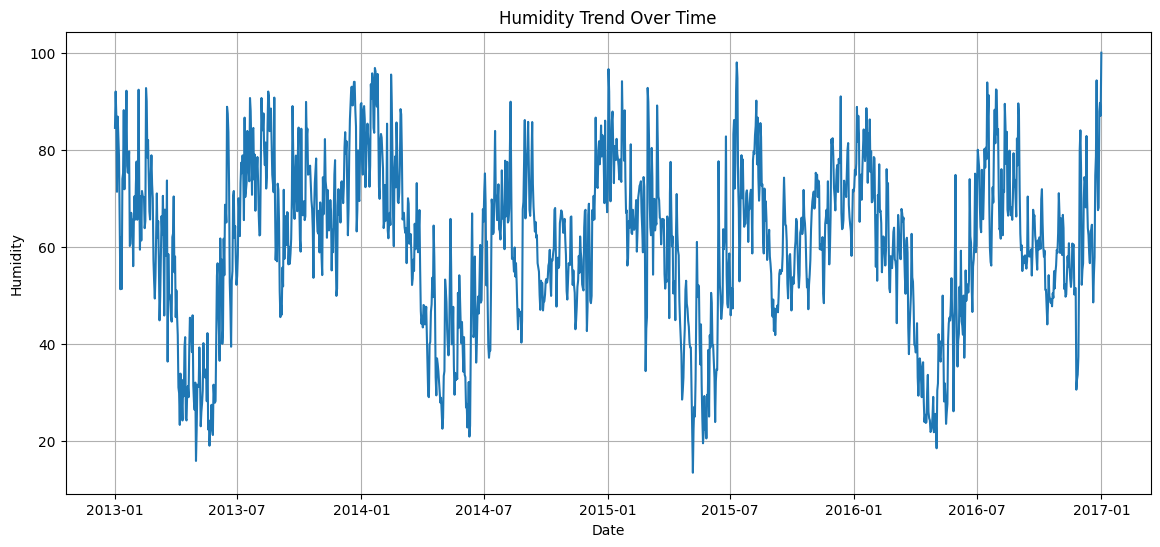

In [11]:
plt.figure(figsize=(14,6))
plt.plot(train_df['date'], train_df['humidity'])
plt.title("Humidity Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Humidity")
plt.grid(True)
plt.show()

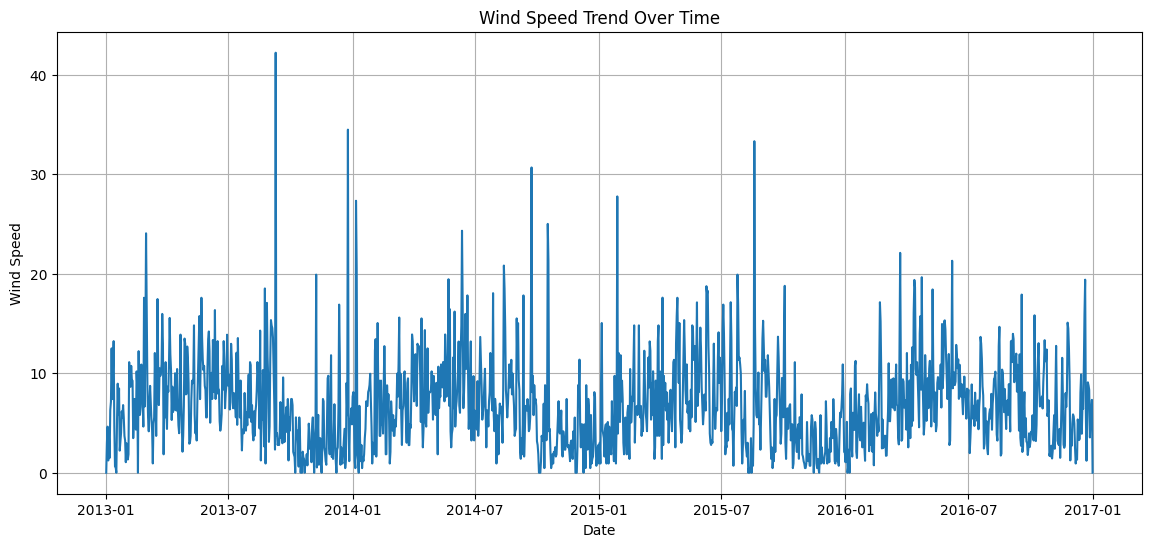

In [12]:
plt.figure(figsize=(14,6))
plt.plot(train_df['date'], train_df['wind_speed'])
plt.title("Wind Speed Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Wind Speed")
plt.grid(True)
plt.show()

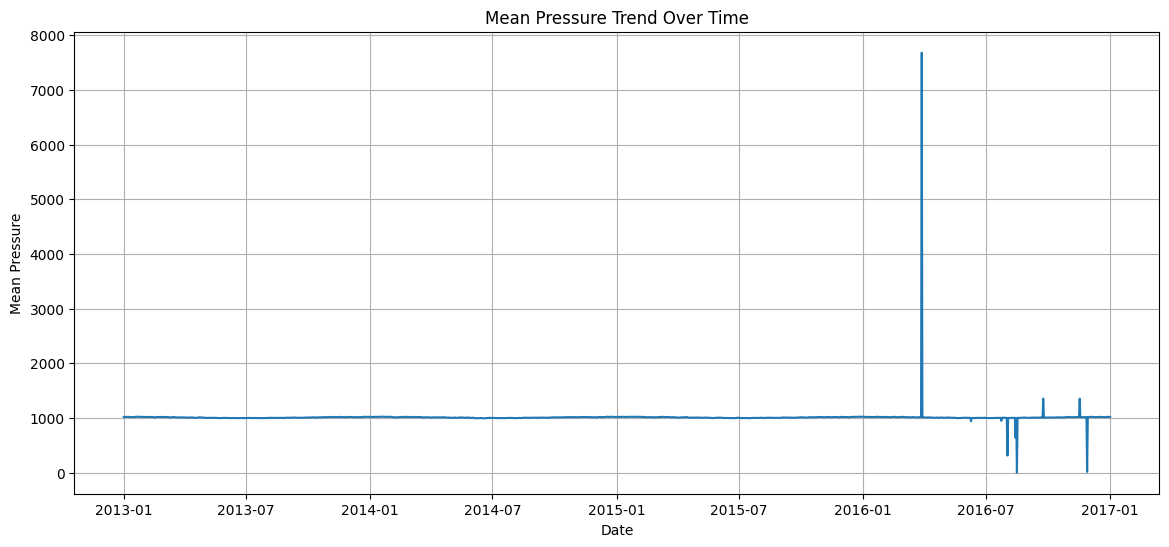

In [13]:
plt.figure(figsize=(14,6))
plt.plot(train_df['date'], train_df['meanpressure'])
plt.title("Mean Pressure Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Mean Pressure")
plt.grid(True)
plt.show()

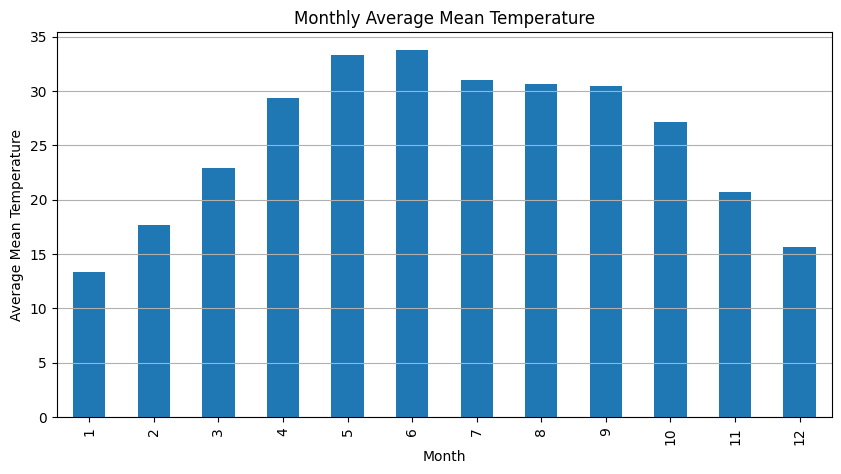

In [14]:
monthly_temp = train_df.groupby('month')['meantemp'].mean()

plt.figure(figsize=(10,5))
monthly_temp.plot(kind='bar')
plt.title("Monthly Average Mean Temperature")
plt.xlabel("Month")
plt.ylabel("Average Mean Temperature")
plt.grid(axis='y')
plt.show()

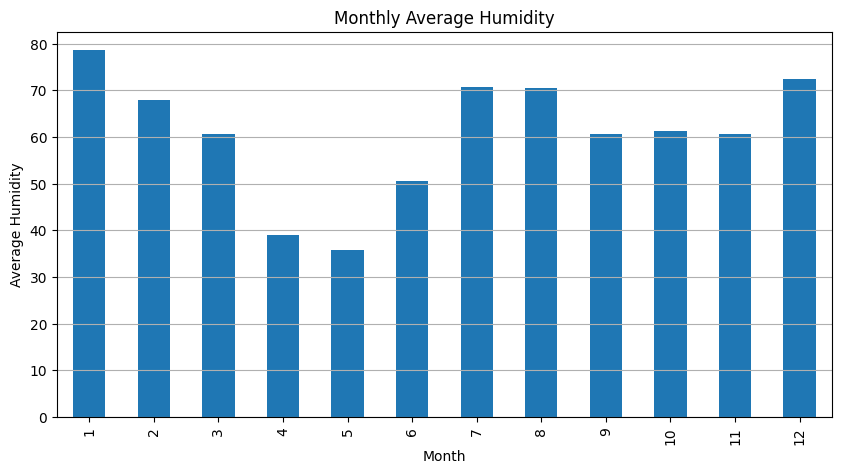

In [15]:
monthly_humidity = train_df.groupby('month')['humidity'].mean()

plt.figure(figsize=(10,5))
monthly_humidity.plot(kind='bar')
plt.title("Monthly Average Humidity")
plt.xlabel("Month")
plt.ylabel("Average Humidity")
plt.grid(axis='y')
plt.show()

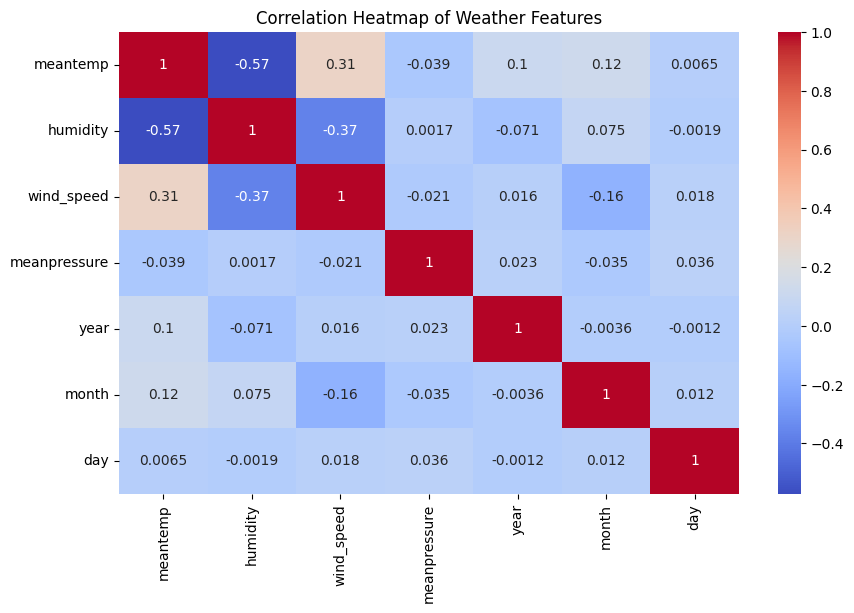

In [16]:
plt.figure(figsize=(10,6))
sns.heatmap(train_df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap of Weather Features")
plt.show()

In [17]:
# Target variable
target = 'meantemp'

# Input features
features = ['humidity', 'wind_speed', 'meanpressure', 'year', 'month', 'day']

X = train_df[features]
y = train_df[target]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
    humidity  wind_speed  meanpressure  year  month  day
0  84.500000    0.000000   1015.666667  2013      1    1
1  92.000000    2.980000   1017.800000  2013      1    2
2  87.000000    4.633333   1018.666667  2013      1    3
3  71.333333    1.233333   1017.166667  2013      1    4
4  86.833333    3.700000   1016.500000  2013      1    5

Target:
0    10.000000
1     7.400000
2     7.166667
3     8.666667
4     6.000000
Name: meantemp, dtype: float64


In [18]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("X_train Shape:", X_train.shape)
print("X_val Shape:", X_val.shape)
print("y_train Shape:", y_train.shape)
print("y_val Shape:", y_val.shape)

X_train Shape: (1169, 6)
X_val Shape: (293, 6)
y_train Shape: (1169,)
y_val Shape: (293,)


In [19]:
lr_model = LinearRegression()

# Train model
lr_model.fit(X_train, y_train)

# Predict on validation data
lr_pred = lr_model.predict(X_val)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [20]:
lr_mae = mean_absolute_error(y_val, lr_pred)
lr_mse = mean_squared_error(y_val, lr_pred)
lr_rmse = np.sqrt(lr_mse)
lr_r2 = r2_score(y_val, lr_pred)

print("Linear Regression Performance")
print("MAE:", lr_mae)
print("MSE:", lr_mse)
print("RMSE:", lr_rmse)
print("R2 Score:", lr_r2)

Linear Regression Performance
MAE: 4.98184386036068
MSE: 36.82178547720517
RMSE: 6.068095704354469
R2 Score: 0.3150638218997368


In [21]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train model
rf_model.fit(X_train, y_train)

# Predict on validation data
rf_pred = rf_model.predict(X_val)

print("Random Forest Regressor model trained successfully!")

Random Forest Regressor model trained successfully!


In [22]:
rf_mae = mean_absolute_error(y_val, rf_pred)
rf_mse = mean_squared_error(y_val, rf_pred)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_val, rf_pred)

print("Random Forest Regressor Performance")
print("MAE:", rf_mae)
print("MSE:", rf_mse)
print("RMSE:", rf_rmse)
print("R2 Score:", rf_r2)

Random Forest Regressor Performance
MAE: 1.2717340158306982
MSE: 3.1668362282872384
RMSE: 1.779560684069874
R2 Score: 0.9410924626613965


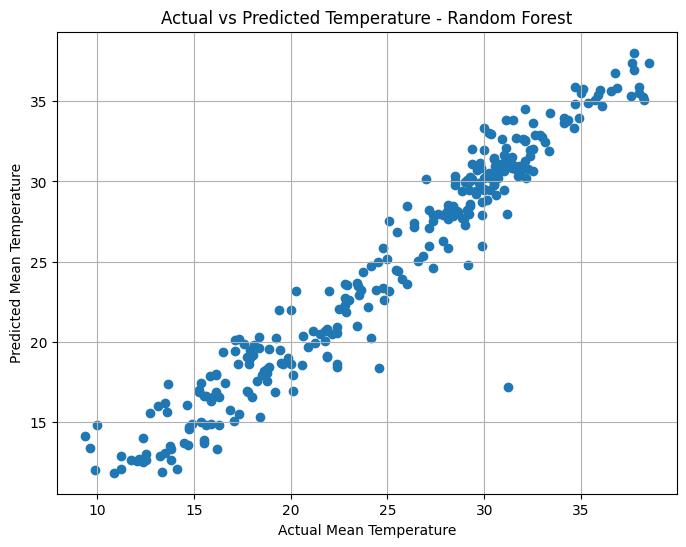

In [23]:
plt.figure(figsize=(8,6))
plt.scatter(y_val, rf_pred)
plt.xlabel("Actual Mean Temperature")
plt.ylabel("Predicted Mean Temperature")
plt.title("Actual vs Predicted Temperature - Random Forest")
plt.grid(True)
plt.show()

In [24]:
model_comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest Regressor'],
    'MAE': [lr_mae, rf_mae],
    'MSE': [lr_mse, rf_mse],
    'RMSE': [lr_rmse, rf_rmse],
    'R2 Score': [lr_r2, rf_r2]
})
model_comparison

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,4.981844,36.821785,6.068096,0.315064
1,Random Forest Regressor,1.271734,3.166836,1.779561,0.941092


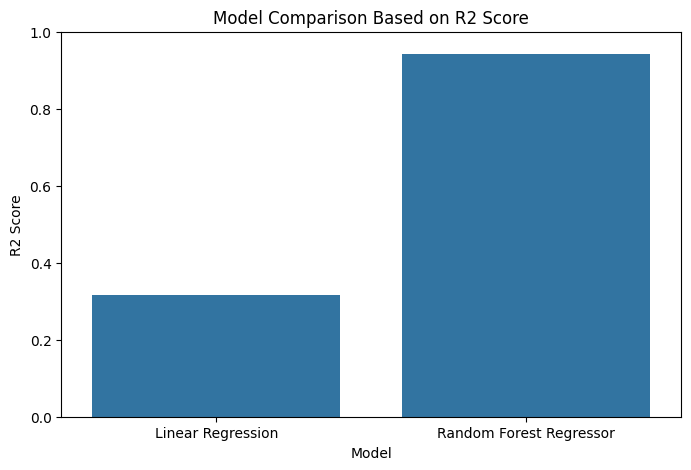

In [25]:
plt.figure(figsize=(8,5))
sns.barplot(x='Model', y='R2 Score', data=model_comparison)
plt.title("Model Comparison Based on R2 Score")
plt.ylim(0, 1)
plt.show()

In [26]:
X_test = test_df[features]
test_predictions = rf_model.predict(X_test)
test_df['Predicted_Mean_Temperature'] = test_predictions
test_df.head()

,date,meantemp,humidity,wind_speed,meanpressure,year,month,day,Predicted_Mean_Temperature
0,2017-01-01,15.913043,85.869565,2.743478,59.000000,2017,1,1,26.190821
1,2017-01-02,18.500000,77.222222,2.894444,1018.277778,2017,1,2,14.607081
2,2017-01-03,17.111111,81.888889,4.016667,1018.333333,2017,1,3,13.957920
3,2017-01-04,18.700000,70.050000,4.545000,1015.700000,2017,1,4,14.672160
4,2017-01-05,18.388889,74.944444,3.300000,1014.333333,2017,1,5,16.895601


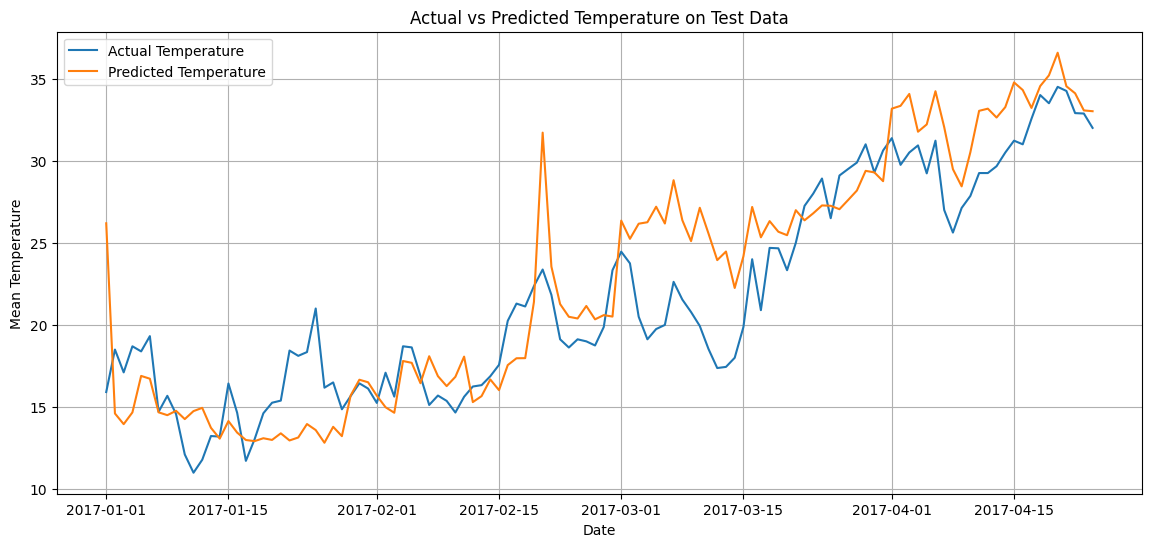

In [27]:
plt.figure(figsize=(14,6))
plt.plot(test_df['date'], test_df['meantemp'], label='Actual Temperature')
plt.plot(test_df['date'], test_df['Predicted_Mean_Temperature'], label='Predicted Temperature')
plt.title("Actual vs Predicted Temperature on Test Data")
plt.xlabel("Date")
plt.ylabel("Mean Temperature")
plt.legend()
plt.grid(True)
plt.show()

In [28]:
test_mae = mean_absolute_error(test_df['meantemp'], test_df['Predicted_Mean_Temperature'])
test_mse = mean_squared_error(test_df['meantemp'], test_df['Predicted_Mean_Temperature'])
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(test_df['meantemp'], test_df['Predicted_Mean_Temperature'])

print("Test Data Performance")
print("MAE:", test_mae)
print("MSE:", test_mse)
print("RMSE:", test_rmse)
print("R2 Score:", test_r2)

Test Data Performance
MAE: 2.5923693781284007
MSE: 10.969830847082202
RMSE: 3.3120734966305023
R2 Score: 0.7264086924172557


In [29]:
test_df.to_csv("weather_temperature_predictions.csv", index=False)
print("Prediction CSV saved successfully!")

Prediction CSV saved successfully!


In [30]:
import joblib
joblib.dump(rf_model, "weather_prediction_model.pkl")
print("Model saved successfully!")

Model saved successfully!


In [31]:
sample_data = pd.DataFrame({
    'humidity': [60],
    'wind_speed': [8],
    'meanpressure': [1010],
    'year': [2026],
    'month': [5],
    'day': [21]
})
predicted_temp = rf_model.predict(sample_data)
print("Predicted Mean Temperature:", predicted_temp[0])

Predicted Mean Temperature: 27.98710139582638


## Conclusion

In this project, historical weather data was analyzed to understand temperature, humidity, wind speed, and pressure trends. The dataset was cleaned and date-based features such as year, month, and day were extracted.

Exploratory Data Analysis was performed using line charts, bar charts, and correlation heatmaps to identify weather patterns and relationships between variables. Two machine learning models, Linear Regression and Random Forest Regressor, were trained to predict mean temperature.

The Random Forest Regressor performed better compared to Linear Regression because it can capture non-linear relationships between weather parameters. The final model was used to predict mean temperature on the test dataset, and the predicted results were saved in a CSV file.

This project demonstrates the practical use of data analysis, visualization, and machine learning techniques for weather prediction.